<a href="https://colab.research.google.com/github/turkson-michael/Machine-learning-/blob/main/pytorch_Multiclass_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split



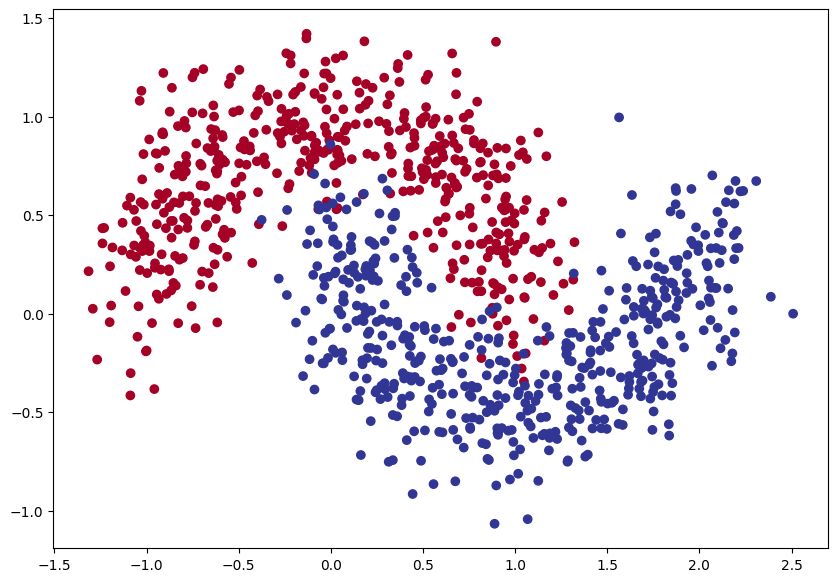

In [ ]:
# Set hyperparameters
NUM_CLASSES = 4
NUM_FEATURES= 2
RANDOM_SEED = 42

#1 . Create a multi-class data
X_moon, y_moon = make_moons(n_samples=1000,
                            shuffle=False,
                            noise=0.2,
                            random_state=RANDOM_SEED)


# 2. turn data into tensors
X_moon =torch.from_numpy(X_moon).type(torch.float)
y_moon = torch.from_numpy(y_moon).type(torch.float)


#3. SPlit into train and test
X_moon_train,X_moon_test,y_moon_train,y_moon_test = train_test_split(X_moon,
                                                                      y_moon,
                                                                     test_size=0.2,
                                                                     random_state=RANDOM_SEED)



#4 .plot data
plt.figure(figsize=(10,7))
plt.scatter(X_moon[:,0], X_moon[:,1], c=y_moon, cmap=plt.cm.RdYlBu)



In [ ]:
y_moon_test.unique()

tensor([0., 1.])

In [ ]:
X_moon_train.shape,y_moon_train.shape

(torch.Size([800, 2]), torch.Size([800]))

## Build a model

In [ ]:
from torch import nn

In [ ]:
class MoonModel(nn.Module):
  def __init__(self, input_features, output_features, hidden_units=10):
    super().__init__()
    self.linear_layer = nn.Sequential(
        nn.Linear(in_features=input_features, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=output_features),
        nn.Sigmoid()
    )

  def forward(self, x):
    return self.linear_layer(x)


In [ ]:
model_1 = MoonModel(input_features=2,
                    output_features=1,
                    hidden_units=10)

In [ ]:
model_1

MoonModel(
  (linear_layer): Sequential(
    (0): Linear(in_features=2, out_features=10, bias=True)
    (1): ReLU()
    (2): Linear(in_features=10, out_features=10, bias=True)
    (3): ReLU()
    (4): Linear(in_features=10, out_features=1, bias=True)
    (5): Sigmoid()
  )
)

In [ ]:
# Create loss and optimizer

loss_fn = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(params=model_1.parameters(),
                            lr=0.1)

In [ ]:
'''
def accuracy_fn(y_true, y_pred):
  correct = torch.eq(y_true, y_pred).sum().item()
  acc = (correct/len(y_pred)) * 100
  return acc
  '''

'\ndef accuracy_fn(y_true, y_pred):\n  correct = torch.eq(y_true, y_pred).sum().item()\n  acc = (correct/len(y_pred)) * 100\n  return acc\n  '

In [ ]:
!pip install torchmetrics

from  torchmetrics import Accuracy

# Setup metric


#Calculate accuracy
#torchmetrics_acc(y_preds, y_blob_test)

In [ ]:
acc = Accuracy(task='binary', num_classes=1)

In [ ]:
y_logits = model_1(X_moon_train).squeeze()
y_pred = torch.sigmoid(y_logits)
yx = torch.round(y_pred)
y_logits[:10], y_pred[:10], yx[:10]


(tensor([0.5090, 0.5045, 0.5031, 0.5044, 0.4994, 0.5047, 0.5054, 0.5007, 0.5025,
         0.5013], grad_fn=<SliceBackward0>),
 tensor([0.6246, 0.6235, 0.6232, 0.6235, 0.6223, 0.6236, 0.6237, 0.6226, 0.6231,
         0.6228], grad_fn=<SliceBackward0>),
 tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.], grad_fn=<SliceBackward0>))

In [ ]:
# Training

torch.manual_seed(42)

epochs = 1000

for epoch in range(epochs):
  #TRain
  model_1.train()

  #1. forward pass
  y_logits = model_1(X_moon_train).squeeze()
  #y_pred = torch.round(torch.sigmoid(y_logits))
  y_pred = torch.round(y_logits)


  #2. loss , acc
  loss = loss_fn(y_logits, y_moon_train)
  acc = Accuracy(task='binary', num_classes=1)(y_pred, y_moon_train)

  #3. optimizer zero grad
  optimizer.zero_grad()

  #4. loss backward
  loss.backward()

  #5. optimizer step
  optimizer.step()


  ### Testing
  model_1.eval()
  with torch.inference_mode():
    test_logits = model_1(X_moon_test).squeeze()
    #test_pred = torch.round(torch.sigmoid(test_logits))
    test_pred = torch.round(test_logits)

    test_loss = loss_fn(test_logits, y_moon_test)
    test_acc = Accuracy(task='binary', num_classes=1)(test_pred, y_moon_test)


  #Print out
  if epoch % 100 == 0:
    print(f'Epoch: {epoch}| Loss: {loss:.5f}, Train Acc: {acc:.2f} % | Test loss: {test_loss:.2f}, TEST ACC: {test_acc:.2f}%')



Epoch: 0| Loss: 0.72753, Train Acc: 0.40 % | Test loss: 0.70, TEST ACC: 0.71%
Epoch: 100| Loss: 0.51943, Train Acc: 0.97 % | Test loss: 0.51, TEST ACC: 0.98%
Epoch: 200| Loss: 0.51887, Train Acc: 0.97 % | Test loss: 0.51, TEST ACC: 0.98%
Epoch: 300| Loss: 0.51859, Train Acc: 0.97 % | Test loss: 0.51, TEST ACC: 0.98%
Epoch: 400| Loss: 0.51890, Train Acc: 0.97 % | Test loss: 0.51, TEST ACC: 0.98%
Epoch: 500| Loss: 0.51893, Train Acc: 0.97 % | Test loss: 0.51, TEST ACC: 0.98%
Epoch: 600| Loss: 0.51946, Train Acc: 0.97 % | Test loss: 0.50, TEST ACC: 0.99%
Epoch: 700| Loss: 0.51930, Train Acc: 0.97 % | Test loss: 0.51, TEST ACC: 0.98%
Epoch: 800| Loss: 0.52016, Train Acc: 0.97 % | Test loss: 0.51, TEST ACC: 0.98%
Epoch: 900| Loss: 0.51870, Train Acc: 0.97 % | Test loss: 0.51, TEST ACC: 0.98%


In [ ]:
yy = model_1(X_moon_test).squeeze()
yy[:10]

tensor([1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00, 3.2033e-18, 1.0000e+00,
        1.0000e+00, 1.0000e+00, 1.0000e+00, 8.6873e-39],
       grad_fn=<SliceBackward0>)

In [ ]:
#make predictions
model_1.eval()
with torch.inference_mode():
  #y_preds = torch.round(torch.sigmoid(model_1(X_moon_test).squeeze()))
  y_preds = torch.round(model_1(X_moon_test).squeeze())

y_preds[:10],y_moon_test[:10]

(tensor([1., 1., 1., 1., 0., 1., 1., 1., 1., 0.]),
 tensor([1., 1., 1., 1., 0., 1., 1., 1., 1., 0.]))

In [ ]:
import requests

In [ ]:
from pathlib import Path

#Download helper functions from Learn Pytorch repo (if its not already downloaded)

if Path("helper_functions.py").is_file():
  print('helper functions.py already exists, skipping download')
else:
  print('Download helper_functions.py')
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

helper functions.py already exists, skipping download


In [ ]:
from helper_functions import plot_predictions, plot_decision_boundary

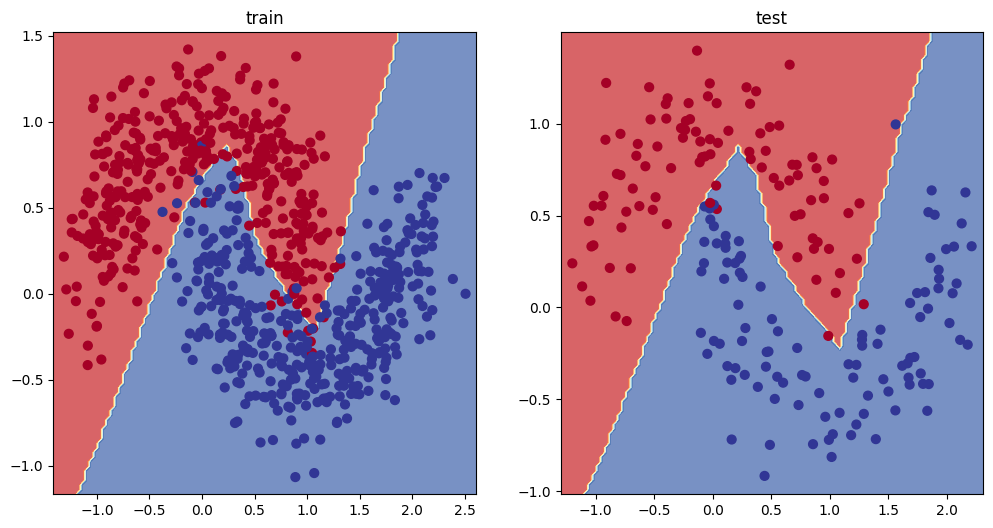

In [ ]:
# plot decision boundaries
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title('train')
plot_decision_boundary(model_1,X_moon_train, y_moon_train)  # Plot for model_3 on training data
plt.subplot(1,2,2)
plt.title('test')
plot_decision_boundary(model_1,X_moon_test, y_moon_test) # Plot for model_3 on test data